# Connected Vehicle Fleet Management with Fleet Analytics using GPS, IoT and Cloud

### Naan Mudhalvan Embedded C Internship Project

**Developed by:** Varsha A

**Domain:** Embedded Systems & IoT

**Tools Used:** Python, Google Colab, GPS Simulation, IoT Simulation, Cloud Analytics

**Objective:**
To simulate a connected vehicle fleet management system that tracks multiple vehicles using GPS data, transmits information through an IoT network, stores data in the cloud, performs fleet analytics, and visualizes vehicle locations and alerts.

# 1. Introduction

Connected Vehicle Fleet Management is a smart transportation system that monitors multiple vehicles in real time. Vehicles continuously send their GPS location and sensor information through IoT communication to a cloud platform.

The cloud processes the received information and performs fleet analytics such as speed monitoring, fuel analysis, engine temperature monitoring, route tracking, and alert generation.

Since physical hardware is unavailable, this project simulates GPS devices, IoT communication, and cloud processing using Python in Google Colab.

# 2. Objectives

• Simulate multiple connected vehicles

• Generate GPS locations

• Simulate IoT communication

• Store vehicle data in cloud

• Perform fleet analytics

• Generate alerts

• Visualize fleet using graphs and maps

# 3. Technologies Used

• Python

• Google Colab

• GPS Simulation

• IoT Simulation

• Cloud Analytics

• Pandas

• NumPy

• Matplotlib

• Plotly

• Folium

• Geopy


In [19]:
!pip install folium geopy plotly


In [20]:
import pandas as pd
import numpy as np
import random
from datetime import datetime

import matplotlib.pyplot as plt

import plotly.express as px

import folium

from geopy.distance import geodesic

# 4. Vehicle Data Generation

This section generates simulated fleet data including GPS coordinates, speed, fuel level, engine temperature, and timestamp for multiple vehicles.

In [21]:
num_vehicles = 10

vehicle_data = []

for i in range(num_vehicles):

    vehicle = {

        "Vehicle_ID": f"V{i+1}",

        "Latitude": round(random.uniform(12.90,13.20),6),

        "Longitude": round(random.uniform(80.10,80.35),6),

        "Speed": random.randint(30,100),

        "Fuel": random.randint(10,100),

        "Temperature": random.randint(70,110),

        "Timestamp": datetime.now()

    }

    vehicle_data.append(vehicle)

df = pd.DataFrame(vehicle_data)

df

,Vehicle_ID,Latitude,Longitude,Speed,Fuel,Temperature,Timestamp
0,V1,12.966367,80.269569,49,90,85,2026-06-28 15:00:25.480789
1,V2,13.156818,80.322426,72,79,89,2026-06-28 15:00:25.480801
2,V3,13.178535,80.155264,92,95,99,2026-06-28 15:00:25.480806
3,V4,13.185537,80.349387,70,20,109,2026-06-28 15:00:25.480811
4,V5,13.188586,80.270456,72,43,103,2026-06-28 15:00:25.480816
5,V6,13.137092,80.145768,42,75,102,2026-06-28 15:00:25.480821
6,V7,13.067454,80.150687,77,12,86,2026-06-28 15:00:25.480825
7,V8,13.177600,80.313592,79,88,79,2026-06-28 15:00:25.480829
8,V9,13.026624,80.177342,38,61,101,2026-06-28 15:00:25.480834
9,V10,13.109745,80.242280,64,94,86,2026-06-28 15:00:25.480838


# 5. Cloud Data Storage

The generated vehicle information is stored in a cloud-based dataframe that acts as the centralized fleet database.

In [22]:
df.to_csv("fleet_data.csv",index=False)

print("Fleet data stored successfully.")

Fleet data stored successfully.


# 6. Fleet Analytics

Fleet analytics calculates vehicle performance statistics including average speed, fuel status, and engine health.

In [23]:
print("Average Speed :",df["Speed"].mean())

print("Maximum Speed :",df["Speed"].max())

print("Minimum Speed :",df["Speed"].min())

print("Average Fuel :",df["Fuel"].mean())

print("Average Temperature :",df["Temperature"].mean())

Average Speed : 65.5
Maximum Speed : 92
Minimum Speed : 38
Average Fuel : 65.7
Average Temperature : 93.9


# 7. GPS Movement Simulation

This section simulates the movement of connected vehicles by continuously updating their GPS coordinates over multiple time intervals. The generated locations represent the real-time movement of vehicles within the fleet.

In [24]:
# GPS Movement Simulation

simulation_data = []

for time_step in range(10):  # Simulate 10 time intervals

    for index, row in df.iterrows():

        latitude = row["Latitude"] + random.uniform(-0.0015, 0.0015)
        longitude = row["Longitude"] + random.uniform(-0.0015, 0.0015)

        speed = max(20, row["Speed"] + random.randint(-5, 5))
        fuel = max(0, row["Fuel"] - random.uniform(0.5, 2))
        temperature = row["Temperature"] + random.randint(-2, 2)

        simulation_data.append({

            "Time": time_step + 1,

            "Vehicle_ID": row["Vehicle_ID"],

            "Latitude": round(latitude, 6),

            "Longitude": round(longitude, 6),

            "Speed": speed,

            "Fuel": round(fuel, 2),

            "Temperature": temperature

        })

simulation_df = pd.DataFrame(simulation_data)

print("GPS Movement Simulation Completed Successfully")

simulation_df.head(20)

GPS Movement Simulation Completed Successfully


,Time,Vehicle_ID,Latitude,Longitude,Speed,Fuel,Temperature
0,1,V1,12.966026,80.268411,47,89.30,85
1,1,V2,13.156188,80.321858,75,77.74,88
2,1,V3,13.177665,80.153814,92,94.13,99
3,1,V4,13.186659,80.350886,73,18.49,108
4,1,V5,13.189117,80.269196,73,41.94,104
5,1,V6,13.137705,80.145614,38,74.14,103
6,1,V7,13.067939,80.151894,78,11.41,85
7,1,V8,13.177574,80.313745,83,86.63,80
8,1,V9,13.027323,80.176508,38,59.68,103
9,1,V10,13.110123,80.243689,68,92.10,84


# 8. IoT Communication Simulation

This section simulates IoT communication where each connected vehicle periodically transmits its GPS location and sensor data such as speed, fuel level, and engine temperature to the cloud server.

In [25]:
# IoT Communication Simulation

print("Simulating IoT Communication...\n")

for index, row in simulation_df.head(20).iterrows():

    print(f"""
Vehicle : {row['Vehicle_ID']}
Time : {row['Time']}
GPS : ({row['Latitude']}, {row['Longitude']})
Speed : {row['Speed']} km/h
Fuel : {row['Fuel']} %
Temperature : {row['Temperature']} °C
Status : Data Successfully Sent to Cloud
""")

Simulating IoT Communication...


Vehicle : V1
Time : 1
GPS : (12.966026, 80.268411)
Speed : 47 km/h
Fuel : 89.3 %
Temperature : 85 °C
Status : Data Successfully Sent to Cloud


Vehicle : V2
Time : 1
GPS : (13.156188, 80.321858)
Speed : 75 km/h
Fuel : 77.74 %
Temperature : 88 °C
Status : Data Successfully Sent to Cloud


Vehicle : V3
Time : 1
GPS : (13.177665, 80.153814)
Speed : 92 km/h
Fuel : 94.13 %
Temperature : 99 °C
Status : Data Successfully Sent to Cloud


Vehicle : V4
Time : 1
GPS : (13.186659, 80.350886)
Speed : 73 km/h
Fuel : 18.49 %
Temperature : 108 °C
Status : Data Successfully Sent to Cloud


Vehicle : V5
Time : 1
GPS : (13.189117, 80.269196)
Speed : 73 km/h
Fuel : 41.94 %
Temperature : 104 °C
Status : Data Successfully Sent to Cloud


Vehicle : V6
Time : 1
GPS : (13.137705, 80.145614)
Speed : 38 km/h
Fuel : 74.14 %
Temperature : 103 °C
Status : Data Successfully Sent to Cloud


Vehicle : V7
Time : 1
GPS : (13.067939, 80.151894)
Speed : 78 km/h
Fuel : 11.41 %
Temperature 

# 9. Cloud Database Update

This section stores the incoming vehicle data in a cloud-based database (simulated using a Pandas DataFrame). The updated dataset is also exported as a CSV file for future analysis and record maintenance.

In [26]:
# Cloud Database Update

simulation_df.to_csv("fleet_simulation.csv", index=False)

print("Cloud Database Updated Successfully")

print()

print("Total Records Stored :", len(simulation_df))

print("Total Vehicles :", simulation_df["Vehicle_ID"].nunique())

simulation_df.tail()

Cloud Database Updated Successfully

Total Records Stored : 100
Total Vehicles : 10


,Time,Vehicle_ID,Latitude,Longitude,Speed,Fuel,Temperature
95,10,V6,13.137697,80.145582,43,73.53,100
96,10,V7,13.067778,80.149783,77,10.26,86
97,10,V8,13.176118,80.314995,76,87.03,80
98,10,V9,13.027983,80.176216,37,59.99,102
99,10,V10,13.109737,80.243288,63,93.36,87


# 10. Distance Travelled by Vehicles

This section calculates the total distance travelled by each vehicle using consecutive GPS coordinates. The geodesic distance between locations is computed to estimate the travelled distance.

In [27]:
# Distance Travelled by Vehicles

print("Distance Travelled by Each Vehicle\n")

vehicle_distances = {}

for vehicle in simulation_df["Vehicle_ID"].unique():

    vehicle_data = simulation_df[simulation_df["Vehicle_ID"] == vehicle]

    total_distance = 0

    vehicle_data = vehicle_data.reset_index(drop=True)

    for i in range(1, len(vehicle_data)):

        point1 = (vehicle_data.loc[i-1, "Latitude"], vehicle_data.loc[i-1, "Longitude"])
        point2 = (vehicle_data.loc[i, "Latitude"], vehicle_data.loc[i, "Longitude"])

        total_distance += geodesic(point1, point2).kilometers

    vehicle_distances[vehicle] = round(total_distance, 2)

distance_df = pd.DataFrame(
    list(vehicle_distances.items()),
    columns=["Vehicle_ID", "Distance(km)"]
)

distance_df

Distance Travelled by Each Vehicle



,Vehicle_ID,Distance(km)
0,V1,1.05
1,V2,1.77
2,V3,1.62
3,V4,1.59
4,V5,1.79
5,V6,1.59
6,V7,1.54
7,V8,2.08
8,V9,1.54
9,V10,1.66


# 11. Speed Analytics

This section analyzes vehicle speed to identify the average, maximum, and minimum speed within the fleet. It also determines the fastest and slowest vehicles for performance evaluation.

In [28]:
print("Speed Analytics\n")

print("Average Speed :", round(simulation_df["Speed"].mean(),2), "km/h")
print("Maximum Speed :", simulation_df["Speed"].max(), "km/h")
print("Minimum Speed :", simulation_df["Speed"].min(), "km/h")

fastest = simulation_df.loc[simulation_df["Speed"].idxmax()]

slowest = simulation_df.loc[simulation_df["Speed"].idxmin()]

print("\nFastest Vehicle :", fastest["Vehicle_ID"])

print("Slowest Vehicle :", slowest["Vehicle_ID"])

Speed Analytics

Average Speed : 64.96 km/h
Maximum Speed : 97 km/h
Minimum Speed : 34 km/h

Fastest Vehicle : V3
Slowest Vehicle : V9


# 12. Fuel Analytics

This section evaluates the fuel status of each vehicle by calculating average fuel levels and identifying vehicles with low fuel that require immediate attention.

In [29]:
print("Fuel Analytics\n")

print("Average Fuel :", round(simulation_df["Fuel"].mean(),2), "%")

lowest = simulation_df.loc[simulation_df["Fuel"].idxmin()]
highest = simulation_df.loc[simulation_df["Fuel"].idxmax()]

print("Lowest Fuel Vehicle :", lowest["Vehicle_ID"])

print("Highest Fuel Vehicle :", highest["Vehicle_ID"])

print("\nVehicles with Fuel Below 20%\n")

low_fuel = simulation_df[simulation_df["Fuel"] < 20]

print(low_fuel[["Vehicle_ID","Fuel"]].drop_duplicates())

Fuel Analytics

Average Fuel : 64.46 %
Lowest Fuel Vehicle : V7
Highest Fuel Vehicle : V3

Vehicles with Fuel Below 20%

   Vehicle_ID   Fuel
3          V4  18.49
6          V7  11.41
13         V4  18.22
16         V7  10.56
23         V4  18.78
26         V7  11.45
33         V4  18.46
36         V7  10.55
43         V4  18.92
46         V7  10.38
53         V4  18.08
56         V7  11.25
63         V4  18.40
66         V7  11.43
73         V4  18.98
76         V7  10.18
83         V4  19.20
86         V7  11.24
93         V4  19.23
96         V7  10.26


# 13. Engine Health Monitoring

This section monitors engine temperature for every vehicle and identifies overheating conditions. Vehicles operating beyond the safe temperature limit are highlighted for maintenance.

In [30]:
print("Engine Health Monitoring\n")

print("Average Temperature :", round(simulation_df["Temperature"].mean(),2), "°C")

print("Maximum Temperature :", simulation_df["Temperature"].max(), "°C")

print("\nVehicles Above 95°C\n")

high_temp = simulation_df[simulation_df["Temperature"] > 95]

print(high_temp[["Vehicle_ID","Temperature"]].drop_duplicates())

Engine Health Monitoring

Average Temperature : 94.14 °C
Maximum Temperature : 111 °C

Vehicles Above 95°C

   Vehicle_ID  Temperature
2          V3           99
3          V4          108
4          V5          104
5          V6          103
8          V9          103
12         V3          100
13         V4          111
14         V5          105
15         V6          100
18         V9          100
24         V5          103
28         V9          102
33         V4          107
35         V6          104
42         V3           98
43         V4          110
55         V6          102
62         V3          101
63         V4          109
64         V5          101
68         V9          101
78         V9           99
84         V5          102


# 14. Fleet Alert System

This section generates real-time alerts based on predefined conditions such as overspeeding, low fuel level, and high engine temperature. The alerts help fleet managers monitor vehicle safety and operational efficiency.

In [31]:
print("Fleet Alert System\n")

alerts = []

latest_data = simulation_df.groupby("Vehicle_ID").tail(1)

for index, row in latest_data.iterrows():

    message = []

    if row["Speed"] > 80:
        message.append("Overspeed")

    if row["Fuel"] < 20:
        message.append("Low Fuel")

    if row["Temperature"] > 95:
        message.append("Engine Overheating")

    if len(message) == 0:
        message.append("Safe")

    alerts.append([row["Vehicle_ID"], ", ".join(message)])

alert_df = pd.DataFrame(alerts, columns=["Vehicle_ID","Alert"])

alert_df

Fleet Alert System



,Vehicle_ID,Alert
0,V1,Safe
1,V2,Safe
2,V3,"Overspeed, Engine Overheating"
3,V4,"Low Fuel, Engine Overheating"
4,V5,Engine Overheating
5,V6,Engine Overheating
6,V7,Low Fuel
7,V8,Safe
8,V9,Engine Overheating
9,V10,Safe


# 15. GPS Fleet Visualization

This section displays the live locations of all vehicles on an interactive GPS map. Each marker represents a vehicle and provides details such as vehicle ID, speed, fuel level, and engine temperature.

In [32]:
fleet_map = folium.Map(location=[13.08,80.27], zoom_start=11)

latest_locations = simulation_df.groupby("Vehicle_ID").tail(1)

for index, row in latest_locations.iterrows():

    popup = f"""
Vehicle : {row['Vehicle_ID']}<br>
Speed : {row['Speed']} km/h<br>
Fuel : {row['Fuel']} %<br>
Temperature : {row['Temperature']} °C
"""

    folium.Marker(
        location=[row["Latitude"], row["Longitude"]],
        popup=popup,
        tooltip=row["Vehicle_ID"]
    ).add_to(fleet_map)

fleet_map

# 16. Vehicle Speed Visualization

This section presents a graphical representation of vehicle speeds using charts. The visualization helps compare the speed of all vehicles within the fleet.

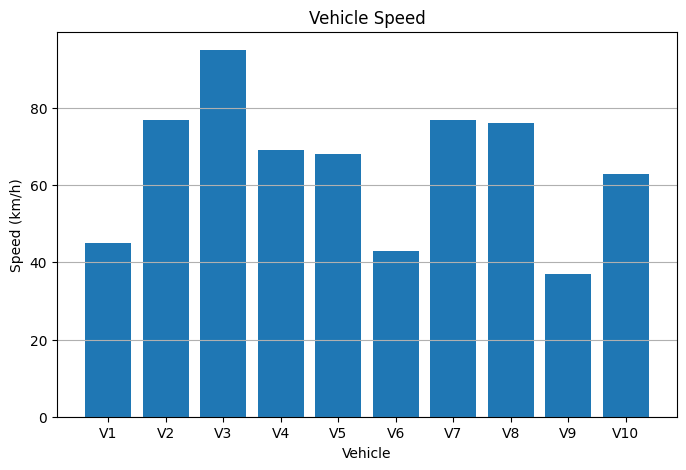

In [33]:
plt.figure(figsize=(8,5))

plt.bar(latest_locations["Vehicle_ID"], latest_locations["Speed"])

plt.title("Vehicle Speed")

plt.xlabel("Vehicle")

plt.ylabel("Speed (km/h)")

plt.grid(axis='y')

plt.show()

# 17. Fuel Level Visualization

This section visualizes the fuel levels of all vehicles using charts, making it easier to identify vehicles with low fuel and compare overall fuel distribution.

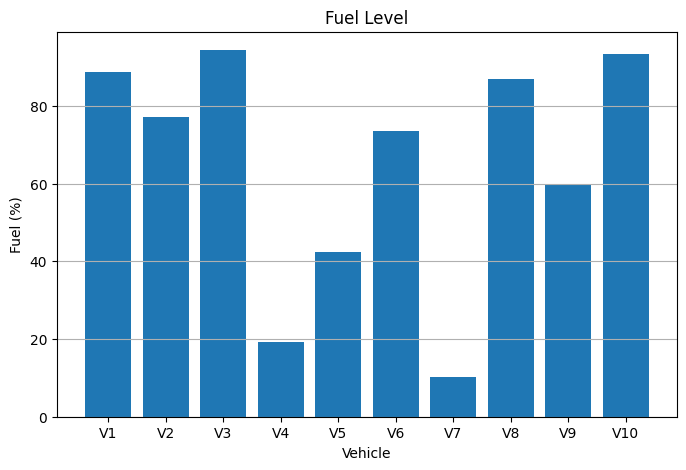

In [34]:
plt.figure(figsize=(8,5))

plt.bar(latest_locations["Vehicle_ID"], latest_locations["Fuel"])

plt.title("Fuel Level")

plt.xlabel("Vehicle")

plt.ylabel("Fuel (%)")

plt.grid(axis='y')

plt.show()

# 18. Engine Temperature Visualization

This section displays the engine temperature of each vehicle through graphical analysis. The visualization helps identify vehicles operating under abnormal temperature conditions.

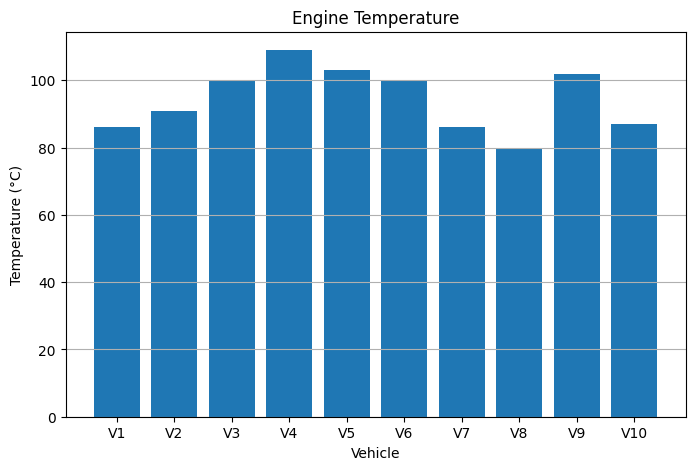

In [35]:
plt.figure(figsize=(8,5))

plt.bar(latest_locations["Vehicle_ID"], latest_locations["Temperature"])

plt.title("Engine Temperature")

plt.xlabel("Vehicle")

plt.ylabel("Temperature (°C)")

plt.grid(axis='y')

plt.show()

# 19. Fleet Performance Summary

This section summarizes the overall fleet performance by displaying important statistics including total vehicles, average speed, average fuel level, average engine temperature, total distance travelled, and the number of vehicles operating safely or requiring attention.

In [36]:
print("Fleet Performance Summary\n")

print("Total Vehicles :", latest_locations["Vehicle_ID"].nunique())

print("Average Speed :", round(latest_locations["Speed"].mean(),2),"km/h")

print("Average Fuel :", round(latest_locations["Fuel"].mean(),2),"%")

print("Average Temperature :", round(latest_locations["Temperature"].mean(),2),"°C")

print("Total Distance Travelled :", round(distance_df["Distance(km)"].sum(),2),"km")

print("Vehicles in Safe Condition :", (alert_df["Alert"]=="Safe").sum())

print("Vehicles with Alerts :", (alert_df["Alert"]!="Safe").sum())

Fleet Performance Summary

Total Vehicles : 10
Average Speed : 65.0 km/h
Average Fuel : 64.61 %
Average Temperature : 94.4 °C
Total Distance Travelled : 16.23 km
Vehicles in Safe Condition : 4
Vehicles with Alerts : 6


# 20. Conclusion

This project successfully simulates a Connected Vehicle Fleet Management System using GPS, IoT, and Cloud technologies in Google Colab. The simulation demonstrates real-time vehicle tracking, cloud-based data storage, fleet analytics, alert generation, and interactive visualizations. Although simulated, the project represents the core functionality of a real-world intelligent fleet management system and can be extended by integrating actual GPS modules, IoT devices, cloud platforms, and embedded hardware for real-time deployment.